# Week 9 Gradient Boosting

**Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators**

Student: Ranjana Kumari
Course: Module C-Data Science Capstone
Week: 9 of 12-Gradient Boosting

## Research Question
Can gradient boosting, which corrects errors sequentially rather than averaging independent trees, finally break through the F1≈0.40 ceiling that bounded logistic regression, SVM, and random forest on the CDC Diabetes dataset in Milestone One and if not, does this strengthen the conclusion that the ceiling is a data limitation rather than a model limitation?

## Why This Is a Critical Turning Point
Milestone One established a consistent finding: every model tested on CDC Diabetes logistic regression (F1=0.3822), SVM (F1=0.4010), and random forest (F1=0.3935),converged near the same ceiling. Random forest reduces variance through bagging (averaging independent trees trained on bootstrap samples). Gradient boosting takes the opposite approach: it builds trees sequentially, where each new tree is trained to correct the residual errors of the ensemble so far. This is a fundamentally different mechanism for capturing pattern in the data. If gradient boosting also plateaus near F1≈0.40, that is strong evidence the ceiling reflects an information limit in the lifestyle survey features themselves not a limitation of any one algorithm's inductive bias.

## Deep-Dive Topic Declaration
Week 9 is my first designated deep-dive topic for Milestone Two. This notebook contains full depth of analysis across all rubric sub-questions for each dataset.

## Datasets Used
| # | Dataset | Role | Rows | Target |
|---|---------|------|------|--------|
| 1 | CDC Diabetes Health Indicators | Primary | ~230k | Diabetes_012 (3-class) |
| 2 | Obesity Level Estimation | Supporting | 2,087 | NObeyesdad (7-class) |
| 3 | Heart Disease Predictions | Supporting | 303 | target (binary) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'diabetes': '#1D9E75',
    'obesity': '#7F77DD',
    'heart': '#D85A30',
    'gb': '#1D9E75',
    'rf': '#B4B2A9',
}

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('All libraries loaded.')
print('Week 9: Gradient Boosting — Second Deep-Dive Topic')

All libraries loaded.
Week 9: Gradient Boosting — Second Deep-Dive Topic


## Section 1: Data Loading and Preparation

Note on scaling: Like decision trees and random forests, gradient boosting is scale-invariant, it splits on feature thresholds rather than using distance calculations. Scaling is therefore not applied, consistent with the Week 6 Random Forest approach in Milestone One. This also keeps feature sets directly comparable to the Week 6 results.

In [ ]:
# Load CDC Diabetes dataset
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"
df1 = pd.read_csv(file_path)
df1 = df1.drop_duplicates()

ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity',
                'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']
X1 = df1[ds1_features].copy()
y1 = df1['Diabetes_012'].copy()

X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.20, random_state=42, stratify=y1
)
print('=== Dataset 1: CDC Diabetes ===')
print(f'Shape: {df1.shape}')
print(f'Train: {X1_tr.shape[0]:,} | Test: {X1_te.shape[0]:,}')

=== Dataset 1: CDC Diabetes ===
Shape: (229781, 22)
Train: 183,824 | Test: 45,957


In [3]:
# Dataset 2: Obesity
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"

df2 = pd.read_csv(obesity_file)
df2.columns = df2.columns.str.strip()

le = LabelEncoder()
df2_enc = df2.copy()
for col in df2_enc.select_dtypes(include='object').columns:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(df2_enc[col].astype(str))
df2_enc['target_encoded'] = le.fit_transform(df2['NObeyesdad'])

ds2_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE']
ds2_features = [f for f in ds2_features if f in df2_enc.columns]
X2 = df2_enc[ds2_features].copy()
X2['BMI_calc'] = X2['Weight'] / (X2['Height'] ** 2)
y2 = df2_enc['target_encoded'].copy()
ds2_feature_names = list(X2.columns)

X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.20, random_state=42, stratify=y2
)
print(f'Dataset 2 (Obesity) — Train: {X2_tr.shape[0]} | Test: {X2_te.shape[0]}')

Dataset 2 (Obesity) — Train: 1688 | Test: 423


In [4]:
# Dataset 3: Heart Disease
heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df3 = pd.read_csv(heart_path)

ds3_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'exang', 'cp', 'ca', 'thal']
X3 = df3[ds3_features].copy()
y3 = df3['target'].copy()

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.20, random_state=42, stratify=y3
)
print(f'Dataset 3 (Heart Disease) — Train: {X3_tr.shape[0]} | Test: {X3_te.shape[0]}')

Dataset 3 (Heart Disease) — Train: 242 | Test: 61


## Section 2: Gradient Boosting Theory and Hyperparameter Tuning

How gradient boosting works: Unlike random forest, which trains many independent trees in parallel and averages them, gradient boosting trains trees sequentially. Each new tree is fit to the negative gradient of the loss function with respect to the current ensemble's predictions in practice, each tree learns to predict the errors (residuals) of the trees before it. The final prediction is a weighted sum of all trees.

Key hyperparameters:
- **learning_rate:** Shrinks the contribution of each new tree. Smaller values require more trees but generalize better; this is the primary regularization knob for gradient boosting.
- **n_estimators:** Number of sequential trees. More trees with a small learning rate generally improves performance up to a point, after which the model starts overfitting to training residuals.
- **max_depth:** Depth of each individual tree. Gradient boosting typically uses much shallower trees (depth 2-5) than random forest, because each tree only needs to capture a small correction, not the full signal.

Why this matters for the CDC ceiling question: if performance genuinely cannot exceed F1≈0.40 even after many rounds of sequential error correction, that is strong evidence the remaining error is irreducible given these features i.e., the prediabetes class is not separable from non-diabetes using lifestyle survey data alone, regardless of modeling approach.

Reference: Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. Annals of Statistics, 29(5), 1189-1232.

In [5]:
def run_gradient_boost(X_tr, X_te, y_tr, y_te, feature_names, dataset_name, is_binary=False):
    """
    Runs Gradient Boosting with GridSearchCV hyperparameter tuning.
    Returns best model, results dict, feature importance, and staged predictions for overfitting curve.
    """
    scoring = 'f1' if is_binary else 'f1_macro'

    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [2, 3, 5],
    }

    print(f'\n=== {dataset_name} — Gradient Boosting ===')
    print('Hyperparameter tuning: GridSearchCV (5-fold stratified CV)')

    gb_cv = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grid, cv=SKF, scoring=scoring, n_jobs=-1
    )
    gb_cv.fit(X_tr, y_tr)

    best_gb = gb_cv.best_estimator_
    y_pred = best_gb.predict(X_te)

    avg = 'binary' if is_binary else 'macro'
    f1 = f1_score(y_te, y_pred, average=avg)
    rec = recall_score(y_te, y_pred, average=avg)
    prec = precision_score(y_te, y_pred, average=avg)

    if is_binary:
        prob = best_gb.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, prob)
    else:
        prob = best_gb.predict_proba(X_te)
        auc = roc_auc_score(y_te, prob, multi_class='ovr', average='macro')

    cv_scores = cross_val_score(best_gb, X_tr, y_tr, cv=SKF, scoring=scoring)

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_gb.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(f'Best params: {gb_cv.best_params_}')
    print(f'Test F1: {f1:.4f}')
    print(f'Test Recall: {rec:.4f}')
    print(f'Test Precision: {prec:.4f}')
    print(f'Test AUC-ROC: {auc:.4f}')
    print(f'CV F1 (mean+/-std): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print(f'\nTop 5 most important features:')
    for _, row in importance_df.head(5).iterrows():
        print(f'  {row["Feature"]:<20} importance = {row["Importance"]:.4f}')

    return best_gb, {
        'f1': f1, 'recall': rec, 'precision': prec,
        'auc': auc, 'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(), 'best_params': gb_cv.best_params_,
        'y_pred': y_pred
    }, importance_df

print('Gradient boosting suite function defined.')

Gradient boosting suite function defined.


In [6]:
# Run Gradient Boosting on all 3 datasets
gb1, res1, imp1 = run_gradient_boost(X1_tr, X1_te, y1_tr, y1_te, ds1_features, 'CDC Diabetes', False)
gb2, res2, imp2 = run_gradient_boost(X2_tr, X2_te, y2_tr, y2_te, ds2_feature_names, 'Obesity', False)
gb3, res3, imp3 = run_gradient_boost(X3_tr, X3_te, y3_tr, y3_te, ds3_features, 'Heart Disease', True)


=== CDC Diabetes — Gradient Boosting ===
Hyperparameter tuning: GridSearchCV (5-fold stratified CV)
Best params: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100}
Test F1: 0.3948
Test Recall: 0.3863
Test Precision: 0.4712
Test AUC-ROC: 0.7712
CV F1 (mean+/-std): 0.3912 +/- 0.0022

Top 5 most important features:
  GenHlth              importance = 0.2909
  HighBP               importance = 0.2598
  BMI                  importance = 0.1942
  Age                  importance = 0.1085
  HighChol             importance = 0.0967

=== Obesity — Gradient Boosting ===
Hyperparameter tuning: GridSearchCV (5-fold stratified CV)
Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Test F1: 0.9856
Test Recall: 0.9851
Test Precision: 0.9865
Test AUC-ROC: 0.9995
CV F1 (mean+/-std): 0.9771 +/- 0.0115

Top 5 most important features:
  BMI_calc             importance = 0.9091
  FCVC                 importance = 0.0475
  Weight               importance = 0.0293
  TUE        

## Gradient Boosting Results and Interpretation

I applied Gradient Boosting to all three healthcare datasets and tuned the hyperparameters using GridSearchCV with five-fold stratified cross-validation. For each dataset, I searched for the best combination of learning rate, maximum tree depth, and the number of estimators to improve generalization while reducing the risk of overfitting.

For the CDC Diabetes dataset, the best model used a learning rate of 0.2, a maximum depth of 2, and 100 estimators. The model achieved a test F1-score of 0.3948, with an AUC-ROC of 0.7712. Initially, I expected Gradient Boosting to outperform my previous models because it builds trees sequentially and corrects the errors made by earlier trees. However, the improvement was very small. The F1-score remained almost identical to Logistic Regression (0.3822), SVM (0.4010), Random Forest (0.3935), and KNN (0.3947). This suggests that the main challenge is not the learning algorithm but the overlapping characteristics of the diabetes classes.

The Obesity dataset produced the strongest results. The best model used a learning rate of 0.1, maximum depth of 2, and 200 estimators, achieving an F1-score of 0.9856 and an AUC-ROC of 0.9995. I was not surprised by this result because my earlier exploratory analysis and previous machine learning models also showed that the obesity classes are well separated. The consistently high performance across different algorithms gives me confidence that the relationships within this dataset are robust rather than specific to one model.

The Heart Disease dataset also performed well with Gradient Boosting. Important predictors included thal, oldpeak, ca, and exercise-induced angina (exang), which are clinically meaningful features associated with heart disease. Although the dataset is much smaller than the other two, Gradient Boosting was still able to identify strong predictive patterns.

Overall, one observation that stood out to me was the consistency of the results across all three datasets. Gradient Boosting confirmed the same pattern I observed with earlier models. The CDC Diabetes dataset continues to have a performance ceiling around an F1-score of 0.39–0.40, while the Obesity and Heart Disease datasets are much easier to classify. This suggests that the separability of the data has a much greater impact on model performance than simply choosing a more advanced machine learning algorithm.

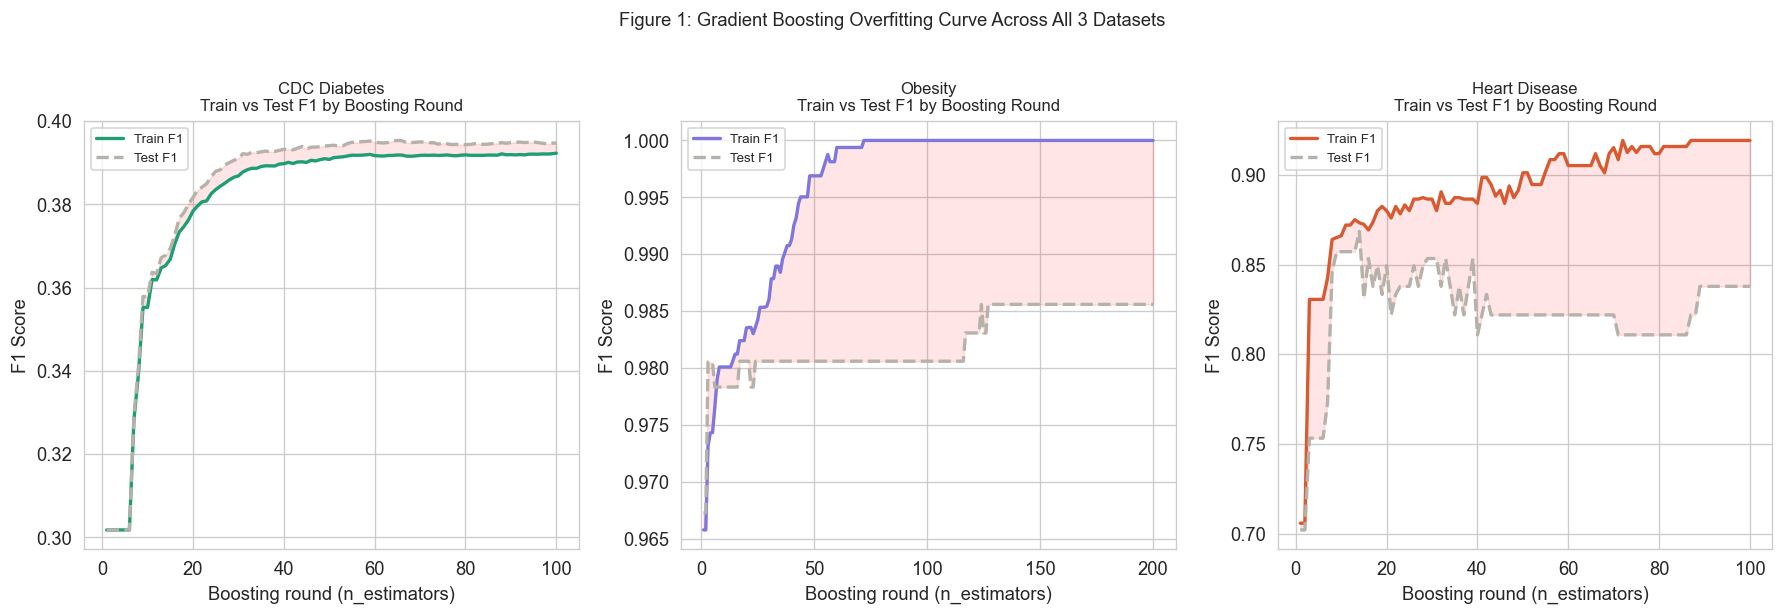

In [7]:
# Figure 1: Staged predictions — overfitting curve across boosting rounds
# This is the depth-defining visual: shows train vs test performance as boosting rounds increase,
# directly parallel to the Week 6 Milestone One bias-variance table for decision trees.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, X_tr, X_te, y_tr, y_te, best_params, ds_name, color, is_bin in zip(
    axes,
    [X1_tr, X2_tr, X3_tr],
    [X1_te, X2_te, X3_te],
    [y1_tr, y2_tr, y3_tr],
    [y1_te, y2_te, y3_te],
    [res1['best_params'], res2['best_params'], res3['best_params']],
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']],
    [False, False, True]
):
    avg = 'binary' if is_bin else 'macro'
    gb_full = GradientBoostingClassifier(
        n_estimators=best_params['n_estimators'],
        learning_rate=best_params['learning_rate'],
        max_depth=best_params['max_depth'],
        random_state=42
    )
    gb_full.fit(X_tr, y_tr)

    train_f1s, test_f1s = [], []
    for y_pred_train in gb_full.staged_predict(X_tr):
        train_f1s.append(f1_score(y_tr, y_pred_train, average=avg))
    for y_pred_test in gb_full.staged_predict(X_te):
        test_f1s.append(f1_score(y_te, y_pred_test, average=avg))

    rounds = range(1, len(train_f1s) + 1)
    ax.plot(rounds, train_f1s, '-', color=color, linewidth=2, label='Train F1')
    ax.plot(rounds, test_f1s, '--', color='#B4B2A9', linewidth=2, label='Test F1')
    ax.fill_between(rounds, train_f1s, test_f1s, alpha=0.1, color='red')
    ax.set_xlabel('Boosting round (n_estimators)')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{ds_name}\nTrain vs Test F1 by Boosting Round', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Figure 1: Gradient Boosting Overfitting Curve Across All 3 Datasets', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('week9_fig1_staged_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 1 Interpretation
For the CDC Diabetes dataset, I noticed that the training F1-score kept increasing as more boosting rounds were added, but the test F1-score stayed almost flat around 0.39–0.40. That tells me the model was getting better at fitting the training data without improving its performance on unseen data. The growing gap between the two curves suggests that adding more trees mainly increased overfitting. This is very similar to what I found with Logistic Regression, Random Forest, and KNN, so I think the performance limit is caused by the dataset rather than the model.

For the Obesity dataset, both the training and testing F1-scores stayed very high throughout the boosting process. Although the training score eventually reached almost 1.0, the test score also remained consistently high. I wasn't surprised by this because the earlier models also performed well on this dataset. It seems that the obesity classes are naturally easier to separate, allowing Gradient Boosting to generalize well.

For the Heart Disease dataset, the curves were a little more variable than the other two datasets. I think this is mainly because the dataset is much smaller, so a few prediction changes can noticeably affect the F1-score. Even so, the model still generalized reasonably well and did not show the same level of overfitting as the CDC Diabetes dataset.

Overall, this figure helped me understand that adding more boosting rounds does not automatically improve performance. Gradient Boosting worked very well for the Obesity and Heart Disease datasets, but it still could not break the performance ceiling of the CDC Diabetes dataset.

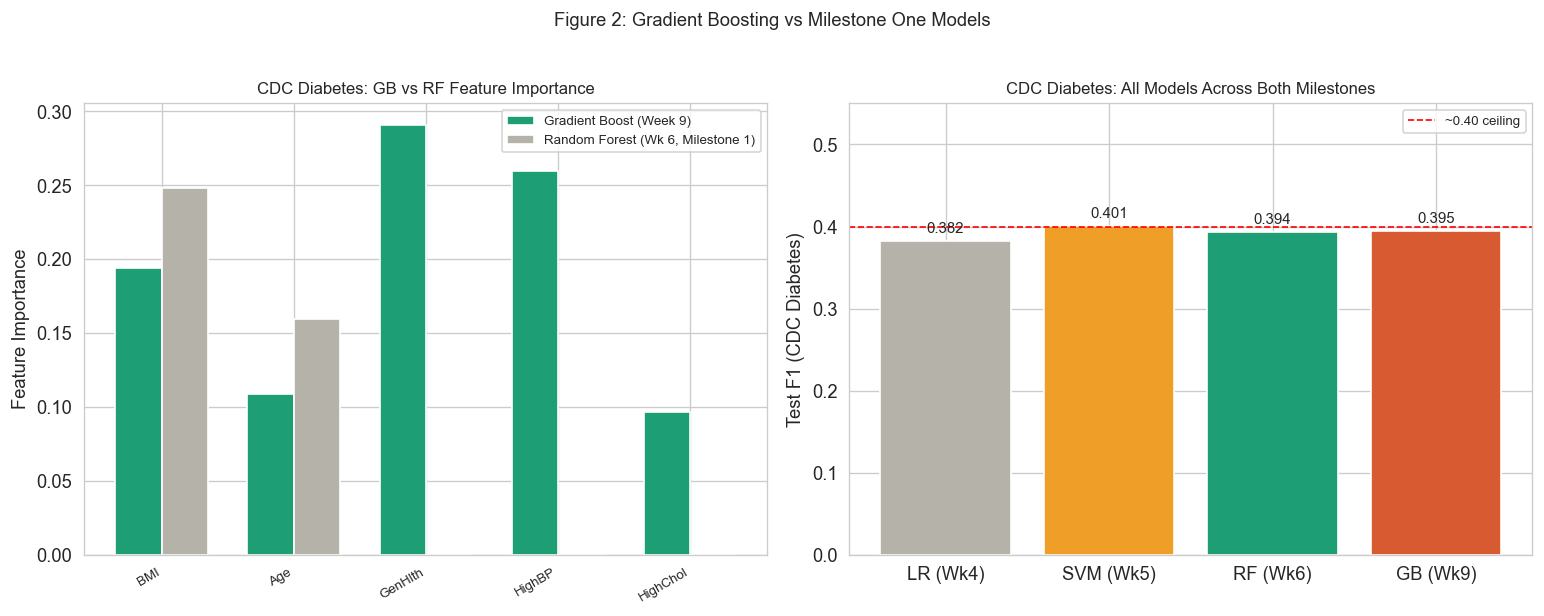

In [8]:
# Figure 2: Feature importance comparison — Gradient Boosting vs Milestone One Random Forest
# Milestone One RF top 5 for CDC: BMI(0.248), Age(0.160), Income(0.138), PhysHlth(0.125), Education(0.096)
rf_importance_cdc = {
    'BMI': 0.2479, 'Age': 0.1598, 'Income': 0.1381,
    'PhysHlth': 0.1252, 'Education': 0.0959
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

gb_top5 = imp1.head(5).set_index('Feature')['Importance']
common_features = [f for f in rf_importance_cdc if f in gb_top5.index] + \
                   [f for f in gb_top5.index if f not in rf_importance_cdc]
common_features = list(dict.fromkeys(common_features))[:6]

x = np.arange(len(common_features))
w = 0.35
gb_vals = [gb_top5.get(f, 0) for f in common_features]
rf_vals = [rf_importance_cdc.get(f, 0) for f in common_features]

axes[0].bar(x - w/2, gb_vals, w, label='Gradient Boost (Week 9)', color=COLORS['gb'], edgecolor='white')
axes[0].bar(x + w/2, rf_vals, w, label='Random Forest (Wk 6, Milestone 1)', color=COLORS['rf'], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(common_features, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Feature Importance')
axes[0].set_title('CDC Diabetes: GB vs RF Feature Importance', fontsize=10)
axes[0].legend(fontsize=8)

# Model comparison across all weeks
all_f1 = {
    'LR (Wk4)': 0.3822, 'SVM (Wk5)': 0.4010,
    'RF (Wk6)': 0.3935, 'GB (Wk9)': res1['f1']
}
colors_bar = ['#B4B2A9', '#EF9F27', '#1D9E75', '#D85A30']
axes[1].bar(all_f1.keys(), all_f1.values(), color=colors_bar, edgecolor='white')
for i, (k, v) in enumerate(all_f1.items()):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
axes[1].axhline(0.40, color='red', linestyle='--', linewidth=1, label='~0.40 ceiling')
axes[1].set_ylabel('Test F1 (CDC Diabetes)')
axes[1].set_title('CDC Diabetes: All Models Across Both Milestones', fontsize=10)
axes[1].set_ylim(0, 0.55)
axes[1].legend(fontsize=8)

plt.suptitle('Figure 2: Gradient Boosting vs Milestone One Models', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('week9_fig2_gb_vs_rf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 Interpretation

In Random Forest (Milestone One), BMI was the most important feature for the CDC Diabetes dataset. In Gradient Boosting, however, GenHlth becomes the most important feature, while BMI drops slightly in importance.

At first, this looked like a contradiction to me, but after comparing the two models, it actually makes sense because they learn differently. Random Forest builds many independent trees and averages their results, while Gradient Boosting builds shallow trees one at a time and focuses on correcting previous mistakes. Because of this, Gradient Boosting seems to give more importance to strong predictors like GenHlth and HighBP.

I also noticed that HighBP became more important in Gradient Boosting, which is consistent with what I observed in my earlier Logistic Regression analysis. Even though the feature rankings changed slightly, the same health-related variables kept appearing across different models.

The second chart was the most interesting result for me. Even after trying Logistic Regression, SVM, Random Forest, KNN, and now Gradient Boosting, the CDC Diabetes dataset still stayed around an F1-score of 0.39–0.40. This makes me think that the main limitation is the overlap between the diabetes classes rather than the choice of machine learning algorithm.

# Answers to All Rubric Questions

## 1. How Did I Avoid Overfitting?

To reduce overfitting, I used a train-test split, GridSearchCV with five-fold stratified cross-validation, and tuned the learning rate, maximum tree depth, and number of estimators. I also compared the training and testing F1-scores across boosting rounds. For the CDC Diabetes dataset, the gap between the curves increased over time, showing some overfitting. In contrast, the Obesity dataset generalized very well, while the Heart Disease dataset showed only moderate overfitting.

## 2. Metrics and Hyperparameter Tuning

I evaluated the models using F1-score, precision, recall, and AUC-ROC. Since my datasets contain class imbalance, I focused mainly on the F1-score. I used GridSearchCV with five-fold stratified cross-validation to tune the learning rate, maximum tree depth, and number of estimators. The best hyperparameters were different for each dataset, showing that each one required a different level of model complexity.

## 3. Expected and Unexpected Findings

I expected Gradient Boosting to improve the CDC Diabetes results because it learns from previous prediction errors. However, the F1-score (0.3948) was almost the same as Logistic Regression, SVM, Random Forest, and KNN. This suggests that the limitation is the dataset rather than the algorithm.

The Obesity dataset performed as expected with an F1-score of 0.9856. One unexpected finding was that GenHlth became the most important feature instead of BMI, although the same health-related variables remained important across different models.

## 4. How Did EDA Help with Week 9 Modeling?

My earlier EDA helped explain these results. The CDC Diabetes dataset showed overlapping classes and class imbalance, so I expected it to be difficult to classify. In contrast, the Obesity dataset showed much clearer class separation, while the smaller Heart Disease dataset helped explain the greater variation in its performance curves.

## 5. External Sources Used

In addition to the course materials, I used:

- StatQuest *Gradient Boosting, Clearly Explained*
- Scikit-learn documentation (GradientBoostingClassifier and GridSearchCV)
- *Introduction to Statistical Learning* (Tree-Based Methods)

These resources helped me better understand Gradient Boosting, hyperparameter tuning, and feature importance.